**Libraries**

In [ ]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA

**Load dataset**

In [ ]:
digits=load_digits()
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

**Visualise**

<Figure size 640x480 with 0 Axes>

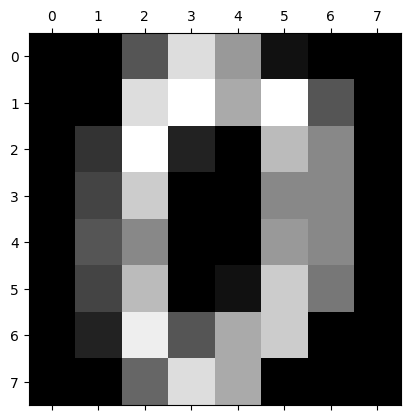

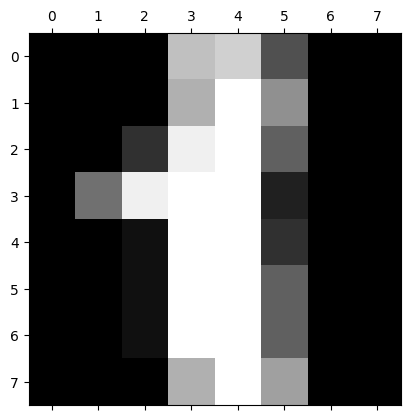

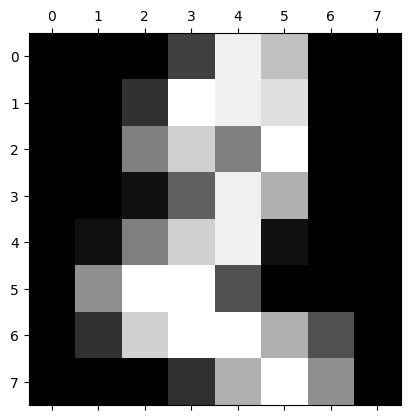

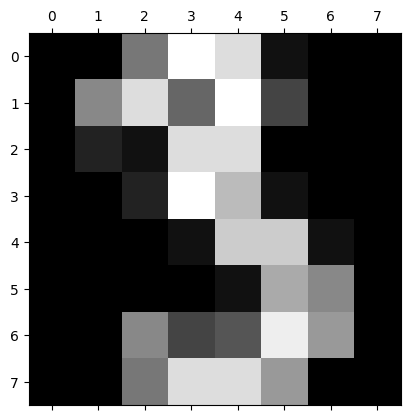

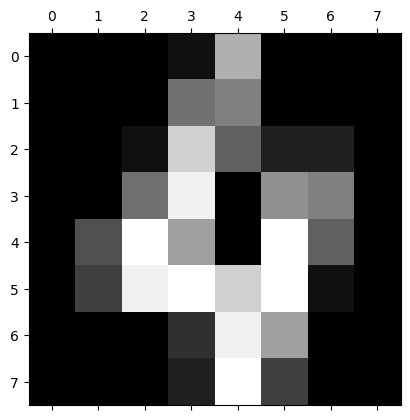

In [ ]:
plt.gray()
for i in range(5):
    plt.matshow(digits.images[i])
    plt.show()

**Features and Target**

In [ ]:
X=digits.data
y=digits.target

**Train Test split**

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**Linear Kernel**

In [12]:
linear_model=SVC(kernel='linear')
linear_model.fit(X_train, y_train)
linear_model.score(X_test, y_test)

0.9777777777777777

**RBF Kernel**

In [13]:
rbf_model=SVC(kernel='rbf')
rbf_model.fit(X_train,y_train)
rbf_model.score(X_test,y_test)

0.9861111111111112

**Tune Gamma**

In [14]:
model1=SVC(kernel='rbf',gamma='scale') #low-gamma
model2=SVC(kernel='rbf',gamma=0.001) #higher-gamma
model3=SVC(kernel='rbf',gamma=0.1) #other

In [16]:
model1.fit(X_train, y_train)
print(model1.score(X_test, y_test))

model2.fit(X_train, y_train)
print(model2.score(X_test, y_test))

model3.fit(X_train, y_train)
print(model3.score(X_test, y_test))

0.9861111111111112
0.9888888888888889
0.07777777777777778


**Tune C**

In [26]:
c1 = SVC(kernel='rbf', C=1)
c2 = SVC(kernel='rbf', C=10)
c3 = SVC(kernel='rbf', C=20)

In [27]:
c1.fit(X_train, y_train)
print(c1.score(X_test, y_test))

c2.fit(X_train, y_train)
print(c2.score(X_test, y_test))

c3.fit(X_train, y_train)
print(c3.score(X_test, y_test))

0.9861111111111112
0.9861111111111112
0.9861111111111112


**Best Model**

In [35]:
best_model = SVC(kernel='rbf',gamma=0.001,C=10)
best_model.fit(X_train, y_train)
best_model.score(X_test, y_test)

0.9888888888888889

**Confusion Matrix**

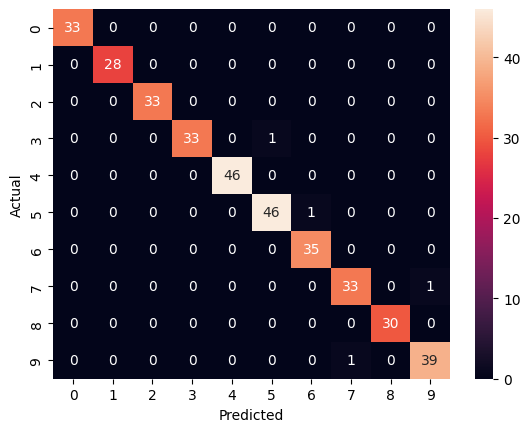

In [36]:
predictions=best_model.predict(X_test)
cm=confusion_matrix(y_test, predictions)
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()